this jupyter file will clean the CICIOT2023 dataset

for speed we randomly select 18 files of the all 169 file in this dataset
you could run all these code for all the files

In [30]:
#imports
import pandas as pd
import numpy as np
import random
import glob
import os

In [31]:
#load files
# Path to folder containing the 18 CSV files
folder_path = './ciciot-dataset-partial'
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Randomly select 5 files from the list
selected_files = random.sample(all_files, 1)

print("Selected files:")
for f in selected_files:
    print(f)

# Read and concatenate ONLY the randomly selected csv files
df_list = [pd.read_csv(file) for file in selected_files]
df = pd.concat(df_list, ignore_index=True)

print(f"\nTotal rows: {df.shape[0]}, Total columns: {df.shape[1]}")


Selected files:
./ciciot-dataset-partial/part-00110-363d1ba3-8ab5-4f96-bc25-4d5862db7cb9-c000.csv

Total rows: 236752, Total columns: 47


In [32]:
# Show the first few rows
display(df.head())

# Check for missing values (NaN)
print("\nMissing values per column:")
print(df.isnull().sum().max()) # Shows maximum missing values in any column

# Check data types 
print("\nData Types:")
print(df.dtypes.value_counts())


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,54.00,6.00,64.00,0.689123,0.689123,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.336103e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SynonymousIP_Flood
1,0.009841,191.14,6.00,65.68,24.135987,24.135987,0.0,0.0,1.0,0.0,...,18.695019,58.82,8.309440e+07,9.5,10.957398,26.472462,1194.724471,0.31,141.55,DDoS-SYN_Flood
2,0.000000,53.46,5.94,63.36,18.932021,18.932021,0.0,0.0,1.0,0.0,...,0.054336,54.06,8.309398e+07,9.5,10.393571,0.077297,0.074720,0.04,141.55,DDoS-SYN_Flood
3,16.052771,209455.40,12.60,63.60,22.170320,22.170320,0.0,0.0,0.0,0.0,...,471.965013,283.20,1.354048e-02,5.5,34.285849,667.459323,253722.562202,0.90,38.50,BenignTraffic
4,0.062471,99.31,6.00,64.00,40.420419,40.420419,0.0,0.0,1.0,0.0,...,27.644510,66.58,8.307703e+07,9.5,10.934937,39.190455,8578.964837,0.09,141.55,DDoS-SYN_Flood



Missing values per column:
0

Data Types:
float64    46
str         1
Name: count, dtype: int64


### Cleaning Data

In [33]:
from sklearn.preprocessing import LabelEncoder

# 1. Replace Infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Drop rows with missing values (NaN)
for col in df.columns:
    if col != 'label':
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

# 3. Encode the target 'label' column to numbers
label_col = 'label' 

encoder = LabelEncoder()
df[label_col] = encoder.fit_transform(df[label_col])


In [34]:
# Show the cleaned data
display(df.head())

# Verify no missing or infinite values exist
print("\nTotal missing values left:", df.isnull().sum().sum())
print("Are there any infinite values left?", np.isinf(df.drop(columns=[label_col])).sum().sum() > 0)

# Verify all columns are now numeric (suitable for ML models)
print("\nCleaned Data Types:")
print(df.dtypes.value_counts())

# Show the mapping of our encoded labels
print("\nLabel Encoding Mapping:")
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(label_mapping)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,54.00,6.00,64.00,0.689123,0.689123,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.336103e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,12
1,0.009841,191.14,6.00,65.68,24.135987,24.135987,0.0,0.0,1.0,0.0,...,18.695019,58.82,8.309440e+07,9.5,10.957398,26.472462,1194.724471,0.31,141.55,10
2,0.000000,53.46,5.94,63.36,18.932021,18.932021,0.0,0.0,1.0,0.0,...,0.054336,54.06,8.309398e+07,9.5,10.393571,0.077297,0.074720,0.04,141.55,10
3,16.052771,209455.40,12.60,63.60,22.170320,22.170320,0.0,0.0,0.0,0.0,...,471.965013,283.20,1.354048e-02,5.5,34.285849,667.459323,253722.562202,0.90,38.50,1
4,0.062471,99.31,6.00,64.00,40.420419,40.420419,0.0,0.0,1.0,0.0,...,27.644510,66.58,8.307703e+07,9.5,10.934937,39.190455,8578.964837,0.09,141.55,10



Total missing values left: 0
Are there any infinite values left? False

Cleaned Data Types:
float64    46
int64       1
Name: count, dtype: int64

Label Encoding Mapping:
{'Backdoor_Malware': np.int64(0), 'BenignTraffic': np.int64(1), 'BrowserHijacking': np.int64(2), 'CommandInjection': np.int64(3), 'DDoS-ACK_Fragmentation': np.int64(4), 'DDoS-HTTP_Flood': np.int64(5), 'DDoS-ICMP_Flood': np.int64(6), 'DDoS-ICMP_Fragmentation': np.int64(7), 'DDoS-PSHACK_Flood': np.int64(8), 'DDoS-RSTFINFlood': np.int64(9), 'DDoS-SYN_Flood': np.int64(10), 'DDoS-SlowLoris': np.int64(11), 'DDoS-SynonymousIP_Flood': np.int64(12), 'DDoS-TCP_Flood': np.int64(13), 'DDoS-UDP_Flood': np.int64(14), 'DDoS-UDP_Fragmentation': np.int64(15), 'DNS_Spoofing': np.int64(16), 'DictionaryBruteForce': np.int64(17), 'DoS-HTTP_Flood': np.int64(18), 'DoS-SYN_Flood': np.int64(19), 'DoS-TCP_Flood': np.int64(20), 'DoS-UDP_Flood': np.int64(21), 'MITM-ArpSpoofing': np.int64(22), 'Mirai-greeth_flood': np.int64(23), 'Mirai-greip_flo

### Train/Test split

In [35]:
from sklearn.model_selection import train_test_split

# Define target column
target_col = 'label'

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Optional: combine for easy inspection
train_df = X_train.copy()
train_df[target_col] = y_train

test_df = X_test.copy()
test_df[target_col] = y_test

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())


Train shape: (189401, 47)
Test shape: (47351, 47)

Train label distribution:
label
6     29140
14    21954
13    18290
8     16651
10    16386
9     16202
12    14580
21    13572
20    10894
19     8271
1      4476
23     4060
25     3629
24     3114
7      1822
22     1203
15     1160
4      1145
16      748
26      527
27      426
29      323
18      313
32      147
5       119
11       99
17       48
30       24
2        19
33       18
3        16
28       11
0        10
31        4
Name: count, dtype: int64

Test label distribution:
label
6     7285
14    5488
13    4573
8     4163
10    4097
9     4051
12    3645
21    3393
20    2724
19    2068
1     1119
23    1015
25     907
24     778
7      456
22     301
15     290
4      286
16     187
26     132
27     107
29      81
18      78
32      36
5       30
11      25
17      12
30       6
2        5
3        4
33       4
0        2
28       2
31       1
Name: count, dtype: int64


### feature scaling

In [36]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Re-attach labels
df_train_scaled = X_train_scaled.copy()
df_train_scaled['label'] = y_train

df_test_scaled = X_test_scaled.copy()
df_test_scaled['label'] = y_test

# Display scaled training data
df_train_scaled.head()


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
12944,-0.016057,-0.135228,0.879501,-0.166715,-0.023311,-0.023311,-0.005054,-0.305728,-0.511293,-0.313297,...,-0.207530,-0.309402,-0.000172,0.006629,-0.362539,-0.207361,-0.097652,-0.285895,0.006396,14
95641,-0.016224,-0.166252,4.218681,-0.166715,-0.090500,-0.090500,-0.005054,-0.305728,-0.511293,-0.313297,...,-0.209063,1.878149,0.031807,0.006629,2.419510,-0.208906,-0.097659,-0.414910,0.006396,24
192358,-0.016224,-0.166252,-0.901395,-0.166715,-0.090703,-0.090703,-0.005054,-0.305728,-0.511293,-0.313297,...,-0.209063,-0.344062,0.001362,0.006629,-0.460002,-0.208906,-0.097659,-0.414910,0.006396,6
146519,-0.016224,-0.166252,4.218681,-0.166715,-0.090772,-0.090772,-0.005054,-0.305728,-0.511293,-0.313297,...,-0.209063,1.936192,0.034333,0.006629,2.466967,-0.208906,-0.097659,-0.414910,0.006396,23
1032,-0.016169,-0.166130,-0.332621,0.014559,-0.090950,-0.090950,-0.005054,-0.305728,-0.511293,-0.313297,...,-0.204122,-0.289501,0.013068,0.006629,-0.315693,-0.203927,-0.097592,-0.285895,0.006396,8


### balancing data

/tmp/ipykernel_6921/354416753.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="tab10")


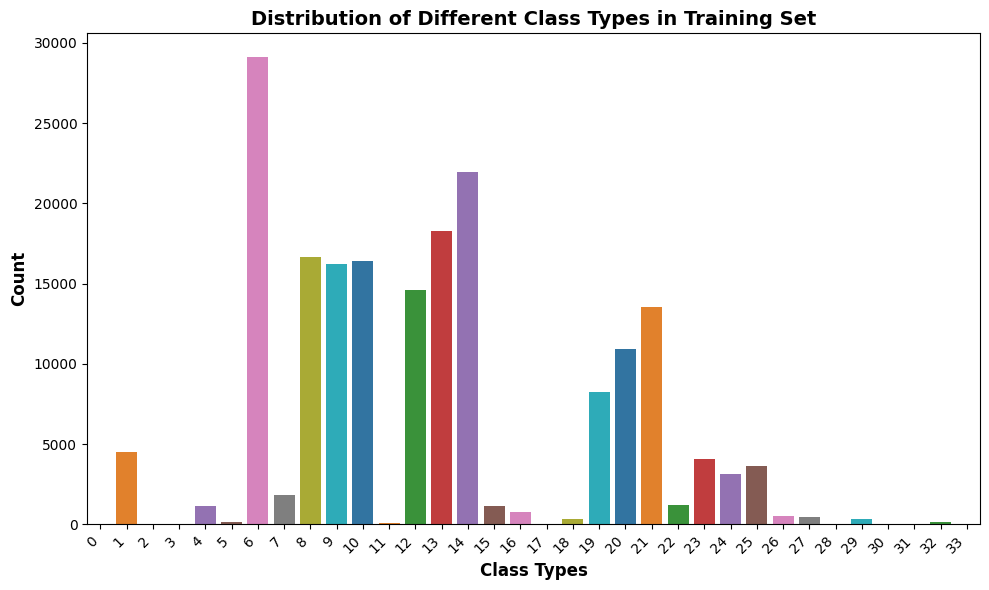

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each class in the training label column
class_counts = df_train_scaled['label'].value_counts().sort_index()

# Set up the figure size
plt.figure(figsize=(10, 6))

# Create the bar plot
sns.barplot(x=class_counts.index, y=class_counts.values, palette="tab10")

# Add titles and labels
plt.title('Distribution of Different Class Types in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Class Types', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')

# Rotate the x-axis labels
plt.xticks(rotation=45, ha='right')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()


/tmp/ipykernel_6921/1262264803.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette="tab10")


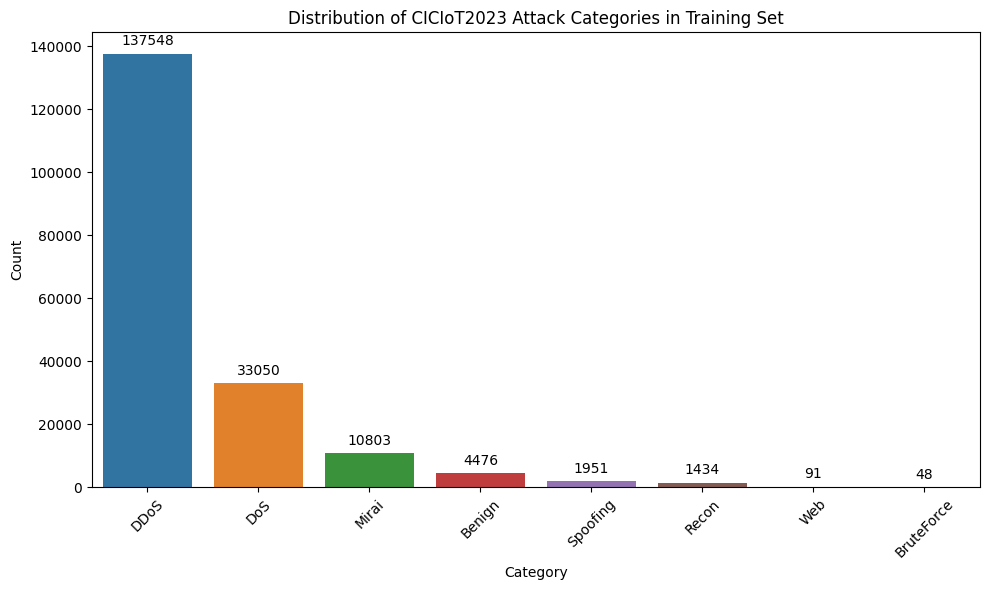

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define the dictionary to map the 34 sub-classes to the 8 main categories
attack_mapping = {
    'BenignTraffic': 'Benign',
    
    'DDoS-ICMP_Flood': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-TCP_Flood': 'DDoS',
    'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-SynonymousIP_Flood': 'DDoS', 'DDoS-ICMP_Fragmentation': 'DDoS', 
    'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS-ACK_Fragmentation': 'DDoS', 
    'DDoS-HTTP_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    
    'DoS-UDP_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PortScan': 'Recon',
    'Recon-PingSweep': 'Recon', 'VulnerabilityScan': 'Recon',
    
    'Mirai-greeth_flood': 'Mirai', 'Mirai-greip_flood': 'Mirai', 'Mirai-udpplain': 'Mirai',
    
    'MITM-ArpSpoofing': 'Spoofing', 'DNS_Spoofing': 'Spoofing',
    
    'DictionaryBruteForce': 'BruteForce',
    
    'BrowserHijacking': 'Web', 'SqlInjection': 'Web', 'CommandInjection': 'Web', 
    'Backdoor_Malware': 'Web', 'XSS': 'Web', 'Uploading_Attack': 'Web'
}


# Work on a copy of training dataframe
df_train_mapped = df_train_scaled.copy()

# Reverse label encoding to original class names
if pd.api.types.is_numeric_dtype(df_train_mapped['label']):
    df_train_mapped['label_string'] = encoder.inverse_transform(df_train_mapped['label'].astype(int))
else:
    df_train_mapped['label_string'] = df_train_mapped['label']

# Map to 8 parent categories
df_train_mapped['category'] = df_train_mapped['label_string'].map(attack_mapping)

# Count category distribution
category_counts = df_train_mapped['category'].value_counts()

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette="tab10")

# Add numbers on bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Distribution of CICIoT2023 Attack Categories in Training Set')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Benign count: 4476
Each attack class will be balanced to: 639

Final distribution after precise balancing:
category
Benign        4476
BruteForce     639
DDoS           639
DoS            639
Mirai          639
Recon          639
Spoofing       639
Web            639
Name: count, dtype: int64


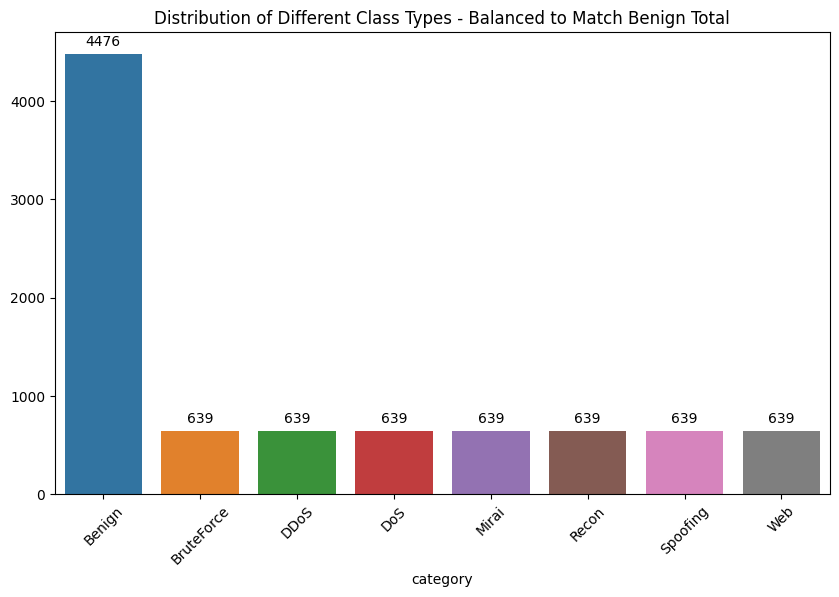

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Since you worked on df_train_mapped in block 9, the SMOTE inputs should be extracted from it
X_train_for_smote = df_train_mapped.drop(columns=['label', 'label_string', 'category'])
y_train_for_smote = df_train_mapped['category']

# 1. Calculate the target value
original_counts = y_train_for_smote.value_counts()
benign_count = original_counts['Benign']
target_val = benign_count // 7  # Target count for each attack class to match the Benign total

print(f"Benign count: {benign_count}")
print(f"Each attack class will be balanced to: {target_val}")

# 2. Separate classes for Over and Under sampling
over_strategy = {}
under_strategy = {}

for cls, count in original_counts.items():
    if cls == 'Benign':
        continue
    if count < target_val:
        # If it is lower, it should be increased (SMOTE)
        over_strategy[cls] = target_val
    elif count > target_val:
        # If it is higher, it should be reduced (UnderSampler)
        under_strategy[cls] = target_val

# 3. First step: increase small classes (SMOTE)
# Only classes that need to be increased are included in over_strategy
if over_strategy:
    smote = SMOTE(sampling_strategy=over_strategy, random_state=42)
    X_over, y_over = smote.fit_resample(X_train_for_smote, y_train_for_smote)
else:
    X_over, y_over = X_train_for_smote, y_train_for_smote

# 4. Second step: reduce large classes (UnderSampler)
# Now all attack classes are either at target_val or above. This makes them exactly equal.
under = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
X_final, y_final = under.fit_resample(X_over, y_over)

# 5. Build the final dataframe
df_train_balanced_final = pd.DataFrame(X_final, columns=X_train_for_smote.columns)
df_train_balanced_final['category'] = y_final

print("\nFinal distribution after precise balancing:")
print(df_train_balanced_final['category'].value_counts())

# 6. Plot the chart (exactly similar to your requested image)
plt.figure(figsize=(10, 6))
final_counts = df_train_balanced_final['category'].value_counts()
ax = sns.barplot(x=final_counts.index, y=final_counts.values, hue=final_counts.index, palette="tab10", legend=False)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.title('Distribution of Different Class Types - Balanced to Match Benign Total')
plt.xticks(rotation=45)
plt.show()


### binary labaling

In [40]:
import pandas as pd

# Make copies
df_train_binary = df_train_mapped.copy()
df_test_binary = df_test_scaled.copy()

# Recover original label strings for test set too
if pd.api.types.is_numeric_dtype(df_test_binary['label']):
    df_test_binary['label_string'] = encoder.inverse_transform(df_test_binary['label'].astype(int))
else:
    df_test_binary['label_string'] = df_test_binary['label']

# Create binary labels: Benign=0, Attack=1
df_train_binary['binary_label'] = df_train_binary['label_string'].apply(
    lambda x: 0 if x == 'BenignTraffic' else 1
)

df_test_binary['binary_label'] = df_test_binary['label_string'].apply(
    lambda x: 0 if x == 'BenignTraffic' else 1
)

print("Train binary label distribution:")
print(df_train_binary['binary_label'].value_counts())

print("\nTest binary label distribution:")
print(df_test_binary['binary_label'].value_counts())


Train binary label distribution:
binary_label
1    184925
0      4476
Name: count, dtype: int64

Test binary label distribution:
binary_label
1    46232
0     1119
Name: count, dtype: int64


In [41]:
# AFTER BALANCING
df_train_binary_balanced = df_train_balanced_final.copy()

df_train_binary_balanced['binary_label'] = df_train_binary_balanced['category'].apply(
    lambda x: 0 if x == 'Benign' else 1
)

print("Train binary label distribution AFTER balancing:")
print(df_train_binary_balanced['binary_label'].value_counts())


Train binary label distribution AFTER balancing:
binary_label
0    4476
1    4473
Name: count, dtype: int64


In [47]:
# Final TRAIN for binary model (balanced)
X_train_final = df_train_binary_balanced.drop(columns=['category', 'binary_label'], errors='ignore')
y_train_final = df_train_binary_balanced['binary_label']

# Final TEST for binary model (original, untouched)
X_test_final = df_test_binary.drop(columns=['label', 'label_string', 'binary_label'], errors='ignore')
y_test_final = df_test_binary['binary_label']

print("X_train_final:", X_train_final.shape)
print("y_train_final:", y_train_final.shape)
print("X_test_final:", X_test_final.shape)
print("y_test_final:", y_test_final.shape)


X_train_final: (8949, 46)
y_train_final: (8949,)
X_test_final: (47351, 46)
y_test_final: (47351,)


### XGBOOST

Training XGBoost binary classification model...
Accuracy : 0.99656
Recall   : 0.99712
Precision: 0.99935
F1 Score : 0.99824


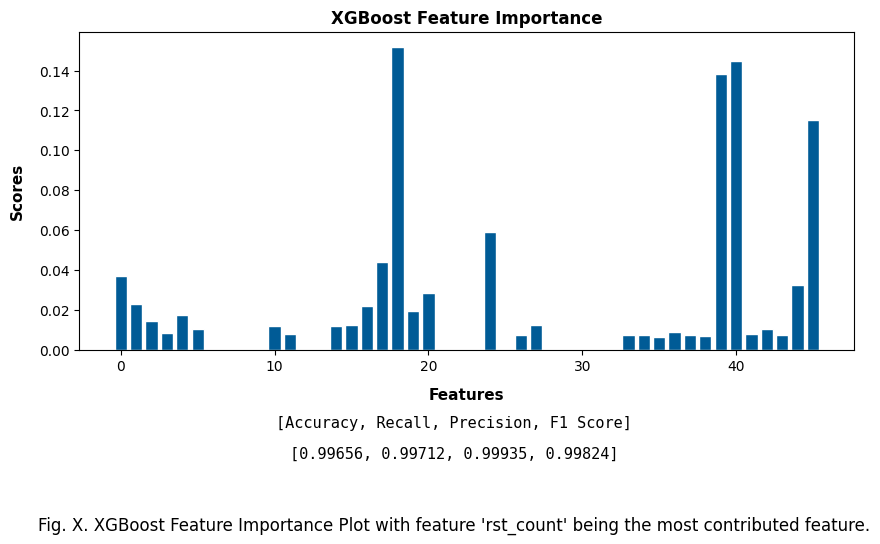

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Binary labels:
# 0 = Normal / No Attack
# 1 = Attack

print("Training XGBoost binary classification model...")

# Initialize XGBoost model for binary classification
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train_final, y_train_final)

# Predict on the test set
y_pred = xgb_model.predict(X_test_final)

# Calculate evaluation metrics
# pos_label=1 means the Attack class is treated as the positive class
accuracy = accuracy_score(y_test_final, y_pred)
recall = recall_score(y_test_final, y_pred, pos_label=1, zero_division=0)
precision = precision_score(y_test_final, y_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_test_final, y_pred, pos_label=1, zero_division=0)

print(f"Accuracy : {accuracy:.5f}")
print(f"Recall   : {recall:.5f}")
print(f"Precision: {precision:.5f}")
print(f"F1 Score : {f1:.5f}")

# Get feature importances
importances = xgb_model.feature_importances_

# Find the most important feature
feature_names = X_train_final.columns
most_important_feat_idx = int(np.argmax(importances))
most_important_feat_name = feature_names[most_important_feat_idx]

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.bar(
    range(len(importances)),
    importances,
    color='#005b96',
    edgecolor='white'
)

plt.xlabel('Features', fontweight='bold', fontsize=11, labelpad=10)
plt.ylabel('Scores', fontweight='bold', fontsize=11, labelpad=10)
plt.title('XGBoost Feature Importance', fontweight='bold', fontsize=12)

# Leave space at the bottom for metrics and caption
plt.subplots_adjust(bottom=0.35)

metrics_headers = "[Accuracy, Recall, Precision, F1 Score]"
metrics_values = f"[{accuracy:.5f}, {recall:.5f}, {precision:.5f}, {f1:.5f}]"

caption = (
    f"XGBoost Feature Importance Plot with feature "
    f"'{most_important_feat_name}' being the most contributed feature."
)

plt.figtext(
    0.5, 0.22,
    metrics_headers,
    ha="center",
    fontsize=11,
    fontfamily='monospace'
)

plt.figtext(
    0.5, 0.17,
    metrics_values,
    ha="center",
    fontsize=11,
    fontfamily='monospace'
)

plt.figtext(
    0.5, 0.05,
    caption,
    ha="center",
    fontsize=12
)

plt.show()


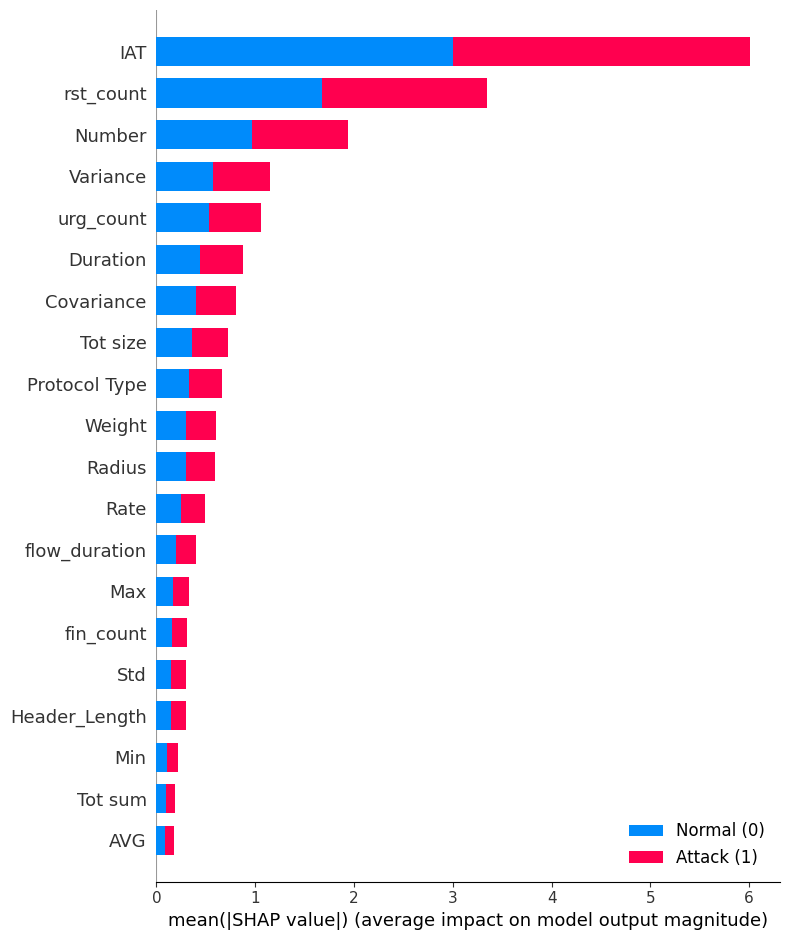

In [65]:
import shap
import matplotlib.pyplot as plt
import numpy as np

X_test_sample = X_test_final.sample(n=5000, random_state=42)

#  Create the SHAP Explainer using the trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

#  Calculate SHAP values for the sample
shap_values = explainer.shap_values(X_test_sample)


shap_values_list = [shap_values * -1, shap_values]

# Define class names for the legend
class_names = ['Normal (0)', 'Attack (1)']

# Generate the Summary Plot (bar chart)
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values_list, 
    X_test_sample, 
    plot_type="bar", 
    class_names=class_names,
    show=False
)

plt.tight_layout()
plt.show()


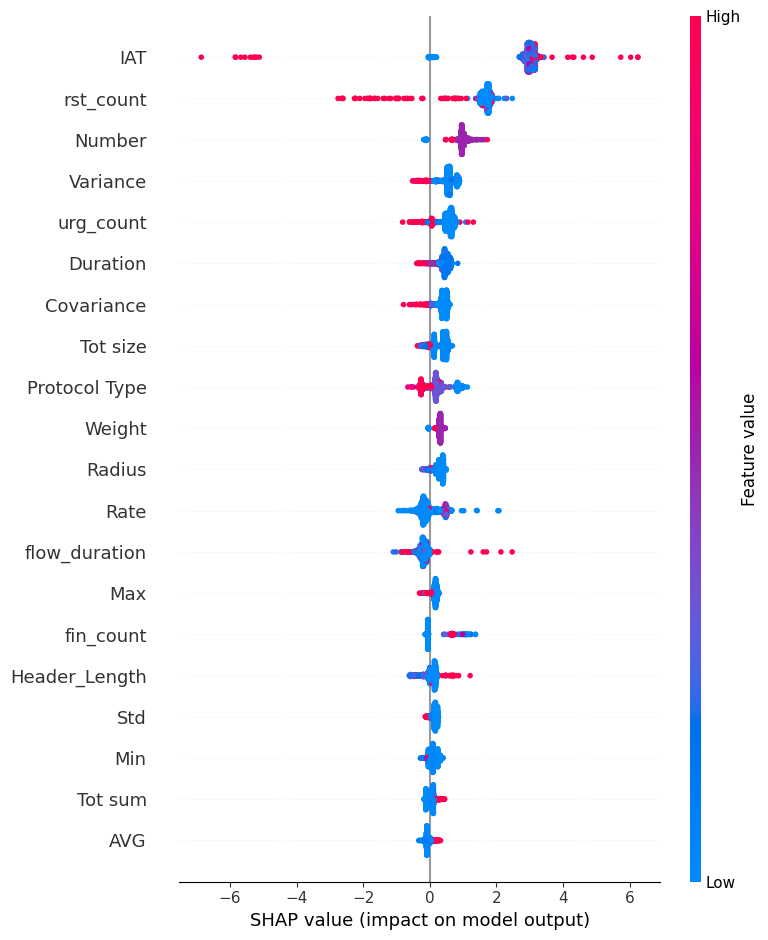

In [66]:
import shap
import matplotlib.pyplot as plt

# Select a test sample
X_test_sample = X_test_final.sample(n=1000, random_state=42)

# Compute SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

# Plot SHAP summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="dot", show=False)

plt.xlabel('SHAP value (impact on model output)')
plt.tight_layout()
plt.show()


/tmp/ipykernel_6921/756563503.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 1])


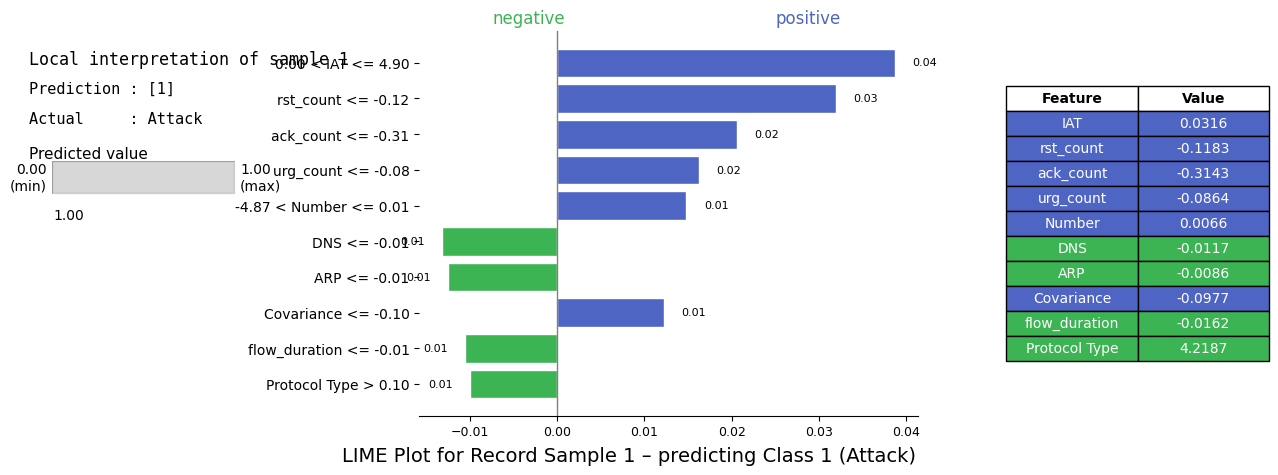

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

# Class names
class_names = ['Normal', 'Attack']

# Build explainer
explainer = LimeTabularExplainer(
    training_data=X_train_final.values,
    feature_names=X_train_final.columns.tolist(),
    class_names=class_names,
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

# Select one sample
sample_index = 0
x_instance = X_test_final.iloc[sample_index].values
x_instance_series = X_test_final.iloc[sample_index]
true_label = int(y_test_final.iloc[sample_index])

# Predict sample
pred_probs = xgb_model.predict_proba(X_test_final.iloc[[sample_index]])[0]
pred_label = int(np.argmax(pred_probs))
pred_prob = float(pred_probs[pred_label])

# Generate explanation
exp = explainer.explain_instance(
    data_row=x_instance,
    predict_fn=xgb_model.predict_proba,
    num_features=10,
    top_labels=2
)

lime_list = exp.as_list(label=pred_label)
all_items = sorted(lime_list, key=lambda x: abs(x[1]), reverse=True)

mid_features = [x[0] for x in all_items]
mid_weights = np.array([x[1] for x in all_items])

# Create layout
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.9, 1.0], wspace=0.25)

ax_left = fig.add_subplot(gs[0, 0])
ax_mid = fig.add_subplot(gs[0, 1])
ax_right = fig.add_subplot(gs[0, 2])

# Left panel
ax_left.axis('off')

ax_left.text(0.00, 0.95, f"Local interpretation of sample {sample_index + 1}",
             fontsize=12, fontfamily='monospace', va='top')
ax_left.text(0.00, 0.84, f"Prediction : [{pred_label}]",
             fontsize=11, fontfamily='monospace')
ax_left.text(0.00, 0.76, f"Actual     : {class_names[true_label]}",
             fontsize=11, fontfamily='monospace')
ax_left.text(0.00, 0.67, "Predicted value", fontsize=11)

bar_x, bar_y, bar_w, bar_h = 0.08, 0.58, 0.60, 0.08

outer_rect = plt.Rectangle((bar_x, bar_y), bar_w, bar_h,
                           fill=False, edgecolor='gray', linewidth=1.2)
ax_left.add_patch(outer_rect)

fill_rect = plt.Rectangle((bar_x, bar_y), bar_w * pred_prob, bar_h,
                          color='lightgray', alpha=0.9)
ax_left.add_patch(fill_rect)

ax_left.text(bar_x - 0.02, bar_y + bar_h / 2, "0.00\n(min)", ha='right', va='center', fontsize=10)
ax_left.text(bar_x + bar_w + 0.02, bar_y + bar_h / 2, "1.00\n(max)", ha='left', va='center', fontsize=10)
ax_left.text(bar_x, bar_y - 0.07, f"{pred_prob:.2f}", ha='left', fontsize=10)

# Middle panel
y_pos = np.arange(len(mid_features))
colors = ['#3CB454' if w < 0 else '#4F65C4' for w in mid_weights]

ax_mid.barh(y_pos, mid_weights, color=colors, edgecolor='white')
ax_mid.axvline(0, color='gray', linewidth=1)
ax_mid.set_yticks(y_pos)
ax_mid.set_yticklabels(mid_features, fontsize=10)
ax_mid.invert_yaxis()

ax_mid.text(0.22, 1.02, 'negative', transform=ax_mid.transAxes,
            color='#3CB454', fontsize=12, ha='center')
ax_mid.text(0.78, 1.02, 'positive', transform=ax_mid.transAxes,
            color='#4F65C4', fontsize=12, ha='center')

for i, w in enumerate(mid_weights):
    if w < 0:
        ax_mid.text(w - 0.002, i, f"{abs(w):.2f}", va='center', ha='right', fontsize=8)
    else:
        ax_mid.text(w + 0.002, i, f"{abs(w):.2f}", va='center', ha='left', fontsize=8)

ax_mid.spines['top'].set_visible(False)
ax_mid.spines['right'].set_visible(False)
ax_mid.spines['left'].set_visible(False)
ax_mid.tick_params(axis='x', labelsize=9)

# Right panel
ax_right.axis('off')

top_feature_names = []
top_feature_values = []

for rule, weight in all_items:
    matched_feature = None
    for col in X_test_final.columns:
        if col in rule:
            matched_feature = col
            break

    if matched_feature is None:
        matched_feature = rule

    top_feature_names.append(matched_feature)

    if matched_feature in x_instance_series.index:
        top_feature_values.append(x_instance_series[matched_feature])
    else:
        top_feature_values.append(np.nan)

table_df = pd.DataFrame({
    'Feature': top_feature_names,
    'Value': top_feature_values
}).head(10)

table_df_display = table_df.copy()
table_df_display['Value'] = table_df_display['Value'].apply(
    lambda x: f"{x:.4f}" if pd.notnull(x) and isinstance(x, (int, float, np.integer, np.floating)) else str(x)
)

table = ax_right.table(
    cellText=table_df_display.values,
    colLabels=table_df_display.columns,
    cellLoc='center',
    colLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

for i in range(1, len(table_df_display) + 1):
    feature_name = table_df.iloc[i - 1, 0]
    weight = 0

    for rule, w in all_items:
        if feature_name in rule:
            weight = w
            break

    color = '#3CB454' if weight < 0 else '#4F65C4'
    table[(i, 0)].set_facecolor(color)
    table[(i, 1)].set_facecolor(color)
    table[(i, 0)].set_text_props(color='white')
    table[(i, 1)].set_text_props(color='white')

table[(0, 0)].set_facecolor('white')
table[(0, 1)].set_facecolor('white')
table[(0, 0)].set_text_props(weight='bold')
table[(0, 1)].set_text_props(weight='bold')

caption = (
    f"LIME Plot for Record Sample {sample_index + 1} – "
    f"predicting Class {pred_label} ({class_names[pred_label]})"
)

plt.figtext(0.5, 0.02, caption, ha='center', fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
